In [1]:
import numpy as np
import json
from os import listdir
from os.path import isfile, join
import matplotlib.pyplot as plt
import seaborn as sns

In [41]:
dirpath = "./data/hardtolearn/UCLK_C/regret_d_8_D_121.50_T_10000_N_200_delta_0.05_epsilon_1e-06/"
files = [f for f in listdir(dirpath) if isfile(join(dirpath, f))]

In [35]:
files

['results_run6.json',
 'results_run7.json',
 'results_run0.json',
 'results_run1.json',
 'results_run2.json',
 'results_run3.json',
 'results_run8.json',
 'results_run4.json',
 'results_run5.json',
 'results_run9.json']

In [42]:
def json_parser(path):
    with open(path) as f:
        data = json.load(f)
        return data['cumulative_regret']

In [43]:
rewards = []
for f in files:
    path = dirpath + f
    rewards.append(json_parser(path))

In [44]:
len(rewards[9])

10000

In [45]:
def running_mean(x, N):
    cumsum = np.cumsum(x, axis=1) 
    return (cumsum[:,N:] - cumsum[:,:-N]) / N

alg_name:  UCLK-C mean reward:  7133587.7 std:  5048443.808620376


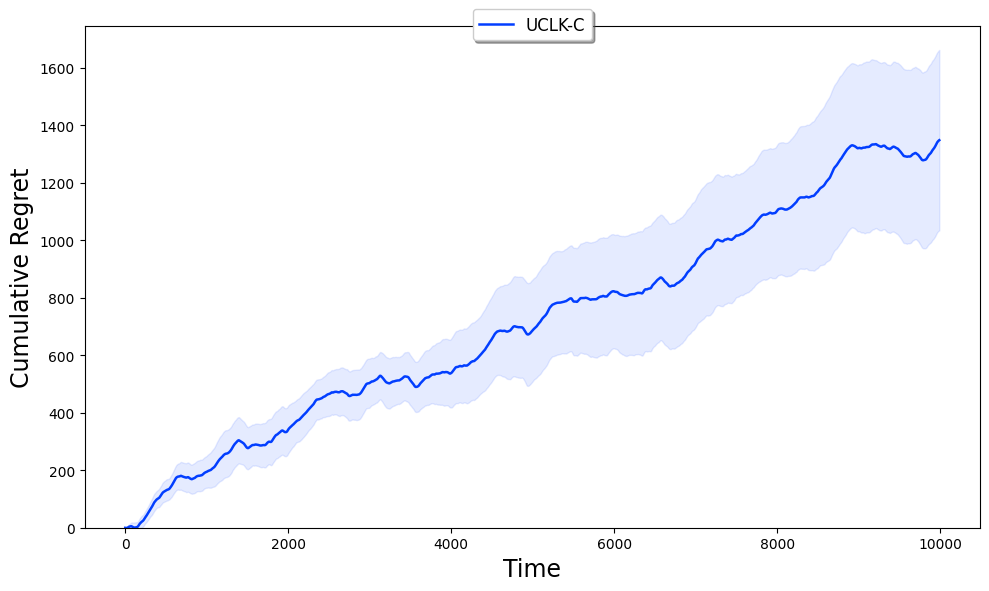

In [50]:
data_mean = np.mean(running_mean(rewards, 10), axis=0)
data_std = np.std(running_mean(rewards, 10), axis=0)
episodes = np.arange(len(data_mean))

algo_list = ['UCLK-C']
colors = sns.color_palette('bright', n_colors=1)
plt.figure(figsize=(10, 6))
plt.rc('font', size=10)        # 기본 폰트 크기
plt.rc('axes', labelsize=17)   # x,y축 label 폰트 크기
plt.rc('xtick', labelsize=10)  # x축 눈금 폰트 크기 
plt.rc('ytick', labelsize=10)  # y축 눈금 폰트 크기
plt.rc('legend', fontsize=12)  # 범례 폰트 크기
# plt.rc('figure', titlesize=50) # figure title 폰트 크기

plt.fill_between(episodes, data_mean + 0.3 * data_std, data_mean - 0.3 * data_std, 
                 alpha=0.1, edgecolor=colors[0], facecolor=colors[0])
plt.plot(episodes, data_mean, color=colors[0], linewidth=1.8, label=algo_list[0])

print("alg_name: ", algo_list[0], "mean reward: ", np.mean(np.sum(rewards, axis=1)), 
      "std: ", np.std(np.sum(rewards, axis=1)))
    
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.05),
           fancybox=True, shadow=True, ncol=3)

plt.xlabel("Time")
plt.ylabel("Cumulative Regret")
plt.ylim(0)
plt.tight_layout()
plt.savefig('(Hard-to-learn, Rewards)_d_8_D_121.50_T_10000_N_200_delta_0.05_epsilon_1e-06' + '.pdf', dpi=300)  # format.pdf
plt.show()